Objective of this notebook is to create a baseline model with minimal cleaning and feature engineering, of which the results can then be used to compare future models against.

In [78]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn import metrics
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split

In [79]:
#Load Dataset
ufc_dataset_df = pd.read_csv('data/ufc-master.csv')

In [80]:
print(ufc_dataset_df.shape)

(4896, 119)


In [81]:
ufc_dataset_df.dtypes

R_fighter      object
B_fighter      object
R_odds        float64
B_odds          int64
R_ev          float64
               ...   
b_dec_odds    float64
r_sub_odds    float64
b_sub_odds    float64
r_ko_odds     float64
b_ko_odds     float64
Length: 119, dtype: object

In [82]:
#Preview Data
pd.set_option('display.max_columns', None)
ufc_dataset_df.head()

,R_fighter,B_fighter,R_odds,B_odds,R_ev,B_ev,date,location,country,Winner,title_bout,weight_class,gender,no_of_rounds,B_current_lose_streak,B_current_win_streak,B_draw,B_avg_SIG_STR_landed,B_avg_SIG_STR_pct,B_avg_SUB_ATT,B_avg_TD_landed,B_avg_TD_pct,B_longest_win_streak,B_losses,B_total_rounds_fought,B_total_title_bouts,B_win_by_Decision_Majority,B_win_by_Decision_Split,B_win_by_Decision_Unanimous,B_win_by_KO/TKO,B_win_by_Submission,B_win_by_TKO_Doctor_Stoppage,B_wins,B_Stance,B_Height_cms,B_Reach_cms,B_Weight_lbs,R_current_lose_streak,R_current_win_streak,R_draw,R_avg_SIG_STR_landed,R_avg_SIG_STR_pct,R_avg_SUB_ATT,R_avg_TD_landed,R_avg_TD_pct,R_longest_win_streak,R_losses,R_total_rounds_fought,R_total_title_bouts,R_win_by_Decision_Majority,R_win_by_Decision_Split,R_win_by_Decision_Unanimous,R_win_by_KO/TKO,R_win_by_Submission,R_win_by_TKO_Doctor_Stoppage,R_wins,R_Stance,R_Height_cms,R_Reach_cms,R_Weight_lbs,R_age,B_age,lose_streak_dif,win_streak_dif,longest_win_streak_dif,win_dif,loss_dif,total_round_dif,total_title_bout_dif,ko_dif,sub_dif,height_dif,reach_dif,age_dif,sig_str_dif,avg_sub_att_dif,avg_td_dif,empty_arena,constant_1,B_match_weightclass_rank,R_match_weightclass_rank,R_Women's Flyweight_rank,R_Women's Featherweight_rank,R_Women's Strawweight_rank,R_Women's Bantamweight_rank,R_Heavyweight_rank,R_Light Heavyweight_rank,R_Middleweight_rank,R_Welterweight_rank,R_Lightweight_rank,R_Featherweight_rank,R_Bantamweight_rank,R_Flyweight_rank,R_Pound-for-Pound_rank,B_Women's Flyweight_rank,B_Women's Featherweight_rank,B_Women's Strawweight_rank,B_Women's Bantamweight_rank,B_Heavyweight_rank,B_Light Heavyweight_rank,B_Middleweight_rank,B_Welterweight_rank,B_Lightweight_rank,B_Featherweight_rank,B_Bantamweight_rank,B_Flyweight_rank,B_Pound-for-Pound_rank,better_rank,finish,finish_details,finish_round,finish_round_time,total_fight_time_secs,r_dec_odds,b_dec_odds,r_sub_odds,b_sub_odds,r_ko_odds,b_ko_odds
0,Thiago Santos,Johnny Walker,-150.0,130,66.666667,130.000000,2021-10-02,"Las Vegas, Nevada, USA",USA,Red,False,Light Heavyweight,MALE,5,0,1,0,3.42,0.59,0.7,0.24,1.00,4,2,11,0,0,0,1,4,0,0,5,Orthodox,198.12,208.28,205,3,0,0,3.95,0.48,0.1,0.61,0.36,4,8,43,1,0,0,2,11,0,0,13,Orthodox,187.96,193.04,205,37,29,-3,1,0,-8,-6,-32,-1,-7,0,10.16,15.24,-8,-0.53,0.6,-0.37,1,1,10.0,5.0,NaN,NaN,NaN,NaN,NaN,5.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,10.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Red,U-DEC,NaN,5.0,5:00,1500.0,800.0,900.0,2000.0,1600.0,-110.0,175.0
1,Alex Oliveira,Niko Price,170.0,-200,170.000000,50.000000,2021-10-02,"Las Vegas, Nevada, USA",USA,Blue,False,Welterweight,MALE,3,2,0,0,5.16,0.42,0.8,0.79,0.22,2,5,24,0,0,0,0,4,2,0,6,Orthodox,182.88,193.04,170,2,0,0,2.97,0.51,0.5,2.27,0.37,4,8,44,0,0,1,3,4,3,0,11,Orthodox,180.34,193.04,170,33,32,0,0,-2,-5,-3,-20,0,0,-1,2.54,0.00,-1,2.19,0.3,-1.48,1,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,neither,U-DEC,NaN,3.0,5:00,900.0,450.0,350.0,700.0,1100.0,550.0,120.0
2,Misha Cirkunov,Krzysztof Jotko,110.0,-130,110.000000,76.923077,2021-10-02,"Las Vegas, Nevada, USA",USA,Blue,False,Middleweight,MALE,3,1,0,0,2.92,0.41,0.1,1.15,0.34,5,5,38,0,0,2,6,1,0,0,9,Southpaw,185.42,195.58,185,1,0,0,3.77,0.49,1.7,4.48,0.44,4,4,13,0,0,0,0,1,5,0,6,Orthodox,190.50,195.58,205,34,32,0,0,1,3,1,25,0,0,-5,-5.08,0.00,-2,-0.85,-1.6,-3.33,1,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,13.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,neither,S-DEC,NaN,3.0,5:00,900.0,550.0,275.0,275.0,1400.0,600.0,185.0
3,Alexander Hernandez,Mike Breeden,-675.0,475,14.814815,475.000000,2021-10-02,"Las Vegas, Nevada, USA",USA,Red,False,Lightweight,MALE,3,1,0,0,4.04,0.34,0.0,0.00,0.00,0,1,3,0,0,0,0,0,0,0,0,Orthodox,177.80,177.80,155,1,0,0,3.79,0.36,0.0,1.57,0.35,2,3,15,0,0,0,2,2,0,0,4,Orthodox,175.26,182.88,155,29,32,0,0,-2,-4,-2,-12,0,-2,0,2.54,-5.08,3,0.25,0.0,-1.57,1,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,N

EDA

Data cleaning and preprocessing


In [83]:
numeric_col = ufc_dataset_df._get_numeric_data().columns
numeric_col

Index(['R_odds', 'B_odds', 'R_ev', 'B_ev', 'title_bout', 'no_of_rounds',
       'B_current_lose_streak', 'B_current_win_streak', 'B_draw',
       'B_avg_SIG_STR_landed',
       ...
       'B_Flyweight_rank', 'B_Pound-for-Pound_rank', 'finish_round',
       'total_fight_time_secs', 'r_dec_odds', 'b_dec_odds', 'r_sub_odds',
       'b_sub_odds', 'r_ko_odds', 'b_ko_odds'],
      dtype='object', length=105)

In [84]:
non_numeric_col = list(set(ufc_dataset_df.columns) - set(numeric_col))
non_numeric_col

['weight_class',
 'R_fighter',
 'country',
 'better_rank',
 'finish',
 'B_Stance',
 'gender',
 'B_fighter',
 'R_Stance',
 'date',
 'finish_details',
 'Winner',
 'finish_round_time',
 'location']

Non-numeric fields will need to either be encoded or removed from the model.

In [96]:
#Select subset of data
#Drop date, location , country, fighter_names for the time being as they hold string data.
#Finish Details anfd total_fight_time_secs not available in dataset for an upcoming event
my_cols = ['R_odds', 'B_odds', 'R_ev', 'B_ev',
       'r_dec_odds', 'b_dec_odds', 'r_sub_odds',
       'b_sub_odds', 'r_ko_odds', 'b_ko_odds', 'Winner']

my_cols = list(numeric_col) + ['Winner'] 

clean_ufc_df = pd.DataFrame(data= ufc_dataset_df, columns=my_cols)
#clean_ufc_df = pd.DataFrame(data= ufc_dataset_df, columns=numeric_col)
clean_ufc_df.head()


,R_odds,B_odds,R_ev,B_ev,title_bout,no_of_rounds,B_current_lose_streak,B_current_win_streak,B_draw,B_avg_SIG_STR_landed,B_avg_SIG_STR_pct,B_avg_SUB_ATT,B_avg_TD_landed,B_avg_TD_pct,B_longest_win_streak,B_losses,B_total_rounds_fought,B_total_title_bouts,B_win_by_Decision_Majority,B_win_by_Decision_Split,B_win_by_Decision_Unanimous,B_win_by_KO/TKO,B_win_by_Submission,B_win_by_TKO_Doctor_Stoppage,B_wins,B_Height_cms,B_Reach_cms,B_Weight_lbs,R_current_lose_streak,R_current_win_streak,R_draw,R_avg_SIG_STR_landed,R_avg_SIG_STR_pct,R_avg_SUB_ATT,R_avg_TD_landed,R_avg_TD_pct,R_longest_win_streak,R_losses,R_total_rounds_fought,R_total_title_bouts,R_win_by_Decision_Majority,R_win_by_Decision_Split,R_win_by_Decision_Unanimous,R_win_by_KO/TKO,R_win_by_Submission,R_win_by_TKO_Doctor_Stoppage,R_wins,R_Height_cms,R_Reach_cms,R_Weight_lbs,R_age,B_age,lose_streak_dif,win_streak_dif,longest_win_streak_dif,win_dif,loss_dif,total_round_dif,total_title_bout_dif,ko_dif,sub_dif,height_dif,reach_dif,age_dif,sig_str_dif,avg_sub_att_dif,avg_td_dif,empty_arena,constant_1,B_match_weightclass_rank,R_match_weightclass_rank,R_Women's Flyweight_rank,R_Women's Featherweight_rank,R_Women's Strawweight_rank,R_Women's Bantamweight_rank,R_Heavyweight_rank,R_Light Heavyweight_rank,R_Middleweight_rank,R_Welterweight_rank,R_Lightweight_rank,R_Featherweight_rank,R_Bantamweight_rank,R_Flyweight_rank,R_Pound-for-Pound_rank,B_Women's Flyweight_rank,B_Women's Featherweight_rank,B_Women's Strawweight_rank,B_Women's Bantamweight_rank,B_Heavyweight_rank,B_Light Heavyweight_rank,B_Middleweight_rank,B_Welterweight_rank,B_Lightweight_rank,B_Featherweight_rank,B_Bantamweight_rank,B_Flyweight_rank,B_Pound-for-Pound_rank,finish_round,total_fight_time_secs,r_dec_odds,b_dec_odds,r_sub_odds,b_sub_odds,r_ko_odds,b_ko_odds,Winner
0,-150.0,130,66.666667,130.000000,False,5,0,1,0,3.42,0.59,0.7,0.24,1.00,4,2,11,0,0,0,1,4,0,0,5,198.12,208.28,205,3,0,0,3.95,0.48,0.1,0.61,0.36,4,8,43,1,0,0,2,11,0,0,13,187.96,193.04,205,37,29,-3,1,0,-8,-6,-32,-1,-7,0,10.16,15.24,-8,-0.53,0.6,-0.37,1,1,10.0,5.0,NaN,NaN,NaN,NaN,NaN,5.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,10.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,5.0,1500.0,800.0,900.0,2000.0,1600.0,-110.0,175.0,Red
1,170.0,-200,170.000000,50.000000,False,3,2,0,0,5.16,0.42,0.8,0.79,0.22,2,5,24,0,0,0,0,4,2,0,6,182.88,193.04,170,2,0,0,2.97,0.51,0.5,2.27,0.37,4,8,44,0,0,1,3,4,3,0,11,180.34,193.04,170,33,32,0,0,-2,-5,-3,-20,0,0,-1,2.54,0.00,-1,2.19,0.3,-1.48,1,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,3.0,900.0,450.0,350.0,700.0,1100.0,550.0,120.0,Blue
2,110.0,-130,110.000000,76.923077,False,3,1,0,0,2.92,0.41,0.1,1.15,0.34,5,5,38,0,0,2,6,1,0,0,9,185.42,195.58,185,1,0,0,3.77,0.49,1.7,4.48,0.44,4,4,13,0,0,0,0,1,5,0,6,190.50,195.58,205,34,32,0,0,1,3,1,25,0,0,-5,-5.08,0.00,-2,-0.85,-1.6,-3.33,1,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,13.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,3.0,900.0,550.0,275.0,275.0,1400.0,600.0,185.0,Blue
3,-675.0,475,14.814815,475.000000,False,3,1,0,0,4.04,0.34,0.0,0.00,0.00,0,1,3,0,0,0,0,0,0,0,0,177.80,177.80,155,1,0,0,3.79,0.36,0.0,1.57,0.35,2,3,15,0,0,0,2,2,0,0,4,175.26,182.88,155,29,32,0,0,-2,-4,-2,-12,0,-2,0,2.54,-5.08,3,0.25,0.0,-1.57,1,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.0,80.0,175.0,900.0,500.0,3500.0,110.0,1100.0,Red
4,-135.0,115,74.074074,115.000000,False,3,0,2,0,5.22,0.56,0.0,2.54,0.39,2,3,19,0,0,0,4,1,0,0,5,175.26,172.72,145,0,4,0,2.64,0.62,0.6,2.85,0.52,4,0,8,0,0,0,2,0,2,0,4,175.26,177.80,155,28,33,0,-2,-2,1,3,11,0,1,-2,0.00,-5.08,5,2.58,-0.6,-0.31,1,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,3.0,900.0,165.0,200.0,400.0,1200.0,900.0,600.0,Blue


In [98]:
#Overall Statistics
clean_ufc_df.describe()
#See Null Values
clean_ufc_df.isnull().sum()

R_odds           1
B_odds           0
R_ev             1
B_ev             0
title_bout       0
              ... 
r_sub_odds    1049
b_sub_odds    1061
r_ko_odds     1049
b_ko_odds     1062
Winner           0
Length: 106, dtype: int64

In [99]:
#For 1st pass, just drop rows with nan values or fill with 0
#clean_ufc_df = clean_ufc_df.dropna(axis = 'index')
clean_ufc_df = clean_ufc_df.fillna(0)


In [100]:
X = clean_ufc_df.loc[:, clean_ufc_df.columns != 'Winner']
y = clean_ufc_df['Winner']

In [101]:
#Create Training and testing Data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=1)

In [102]:
#Compare and plot different results for the different models
model = RandomForestClassifier(random_state=0)

In [103]:
#Fit Model 
model.fit(X_train, y_train)

RandomForestClassifier(random_state=0)

In [104]:
#Evaluate on test data
y_pred = model.predict(X_test)
#Print results
print(y_pred.shape)
print(y_test.shape)

(1224,)
(1224,)


test_accuracy:0.6511437908496732


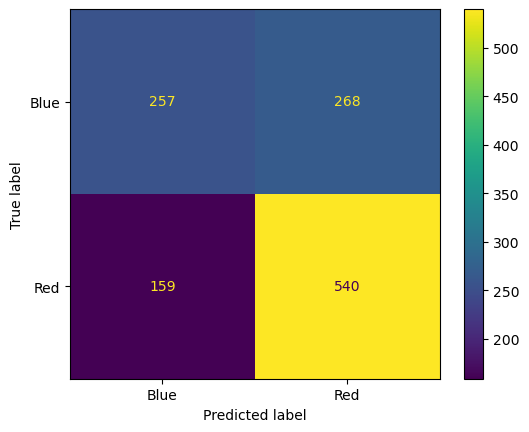

In [105]:
#Get Accuracy
accuracy = metrics.accuracy_score(y_test, y_pred)
print(f'test_accuracy:{accuracy}')

#Display Confusion Matrix
cm = metrics.confusion_matrix(y_test, y_pred, labels=model.classes_)
cm_display = metrics.ConfusionMatrixDisplay(confusion_matrix = cm, display_labels=model.classes_)

#Display CM
cm_display.plot()
plt.show()

Assess the most significant features

Text(0.5, 0, 'Random Forest Feature Importance Sort')

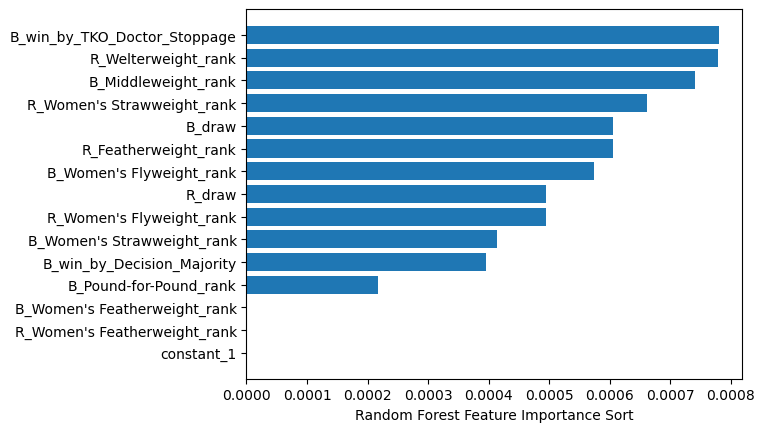

In [107]:
#feature_importances=pd.DataFrame({'features':X.columns,'feature_importance':best_grid.feature_importances_})
feature_importances=pd.DataFrame({'features':X_train.columns,'feature_importance':model.feature_importances_})
sorted_idx = model.feature_importances_.argsort()
sorted_idx_15 = sorted_idx[:15]
plt.barh(feature_importances.features[sorted_idx_15], model.feature_importances_[sorted_idx_15])
plt.xlabel("Random Forest Feature Importance Sort")

Predict Winners for upcoming event

In [ ]:
#From the most accurate model, use this data to predict the winner of a more recent card
upcoming_event = pd.read_csv('data/upcoming-event.csv')

upcoming_event.head()

,R_fighter,B_fighter,R_odds,B_odds,R_ev,B_ev,date,location,country,Winner,title_bout,weight_class,gender,no_of_rounds,B_current_lose_streak,B_current_win_streak,B_draw,B_avg_SIG_STR_landed,B_avg_SIG_STR_pct,B_avg_SUB_ATT,B_avg_TD_landed,B_avg_TD_pct,B_longest_win_streak,B_losses,B_total_rounds_fought,B_total_title_bouts,B_win_by_Decision_Majority,B_win_by_Decision_Split,B_win_by_Decision_Unanimous,B_win_by_KO/TKO,B_win_by_Submission,B_win_by_TKO_Doctor_Stoppage,B_wins,B_Stance,B_Height_cms,B_Reach_cms,B_Weight_lbs,R_current_lose_streak,R_current_win_streak,R_draw,R_avg_SIG_STR_landed,R_avg_SIG_STR_pct,R_avg_SUB_ATT,R_avg_TD_landed,R_avg_TD_pct,R_longest_win_streak,R_losses,R_total_rounds_fought,R_total_title_bouts,R_win_by_Decision_Majority,R_win_by_Decision_Split,R_win_by_Decision_Unanimous,R_win_by_KO/TKO,R_win_by_Submission,R_win_by_TKO_Doctor_Stoppage,R_wins,R_Stance,R_Height_cms,R_Reach_cms,R_Weight_lbs,R_age,B_age,lose_streak_dif,win_streak_dif,longest_win_streak_dif,win_dif,loss_dif,total_round_dif,total_title_bout_dif,ko_dif,sub_dif,height_dif,reach_dif,age_dif,sig_str_dif,avg_sub_att_dif,avg_td_dif,empty_arena,constant_1,B_match_weightclass_rank,R_match_weightclass_rank,R_Women's Flyweight_rank,R_Women's Featherweight_rank,R_Women's Strawweight_rank,R_Women's Bantamweight_rank,R_Heavyweight_rank,R_Light Heavyweight_rank,R_Middleweight_rank,R_Welterweight_rank,R_Lightweight_rank,R_Featherweight_rank,R_Bantamweight_rank,R_Flyweight_rank,R_Pound-for-Pound_rank,B_Women's Flyweight_rank,B_Women's Featherweight_rank,B_Women's Strawweight_rank,B_Women's Bantamweight_rank,B_Heavyweight_rank,B_Light Heavyweight_rank,B_Middleweight_rank,B_Welterweight_rank,B_Lightweight_rank,B_Featherweight_rank,B_Bantamweight_rank,B_Flyweight_rank,B_Pound-for-Pound_rank,better_rank,finish,finish_details,finish_round,finish_round_time,total_fight_time_secs,r_dec_odds,b_dec_odds,r_sub_odds,b_sub_odds,r_ko_odds,b_ko_odds
0,Mackenzie Dern,Marina Rodriguez,-195,165,51.282051,165.000000,2021-10-09,"Las Vegas, Nevada, USA",USA,NaN,False,Women's Strawweight,FEMALE,5,0,2,2,4.89,0.48,0.1,0.28,0.33,2,1,23,0,0,0,3,2,0,0,5,Orthodox,167.64,165.10,115,0,4,0,3.64,0.38,2.3,0.51,0.10,4,1,13,0,0,1,1,0,4,0,6,Orthodox,162.56,160.02,115,28,34,0,-2,-2,-1,0,10,0,2,-4,5.08,5.08,6,1.25,-2.2,-0.23,1,1,6.0,4.0,NaN,NaN,4.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,12.0,NaN,NaN,6.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Red,NaN,NaN,NaN,NaN,NaN,500,400.0,100,2800.0,900,380.0
1,Randy Brown,Jared Gooden,-265,215,37.735849,215.000000,2021-10-09,"Las Vegas, Nevada, USA",USA,NaN,False,Welterweight,MALE,3,0,1,0,5.04,0.42,0.0,0.96,1.00,1,2,7,0,0,0,0,1,0,0,1,Orthodox,182.88,195.58,170,0,1,0,3.72,0.47,0.7,0.98,0.46,2,4,26,0,0,0,2,2,3,0,7,Orthodox,190.50,198.12,170,31,27,0,0,-1,-6,-2,-19,0,-1,-3,-7.62,-2.54,-4,1.32,-0.7,-0.02,1,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,neither,NaN,NaN,NaN,NaN,NaN,200,550.0,400,1600.0,215,500.0
2,Tim Elliott,Matheus Nicolau,155,-180,155.000000,55.555556,2021-10-09,"Las Vegas, Nevada, USA",USA,NaN,False,Flyweight,MALE,3,0,1,0,3.79,0.52,1.4,1.93,0.44,3,1,13,0,0,2,1,0,1,0,4,Orthodox,167.64,167.64,125,0,2,0,3.35,0.45,1.1,4.01,0.49,2,9,39,1,0,0,5,0,1,0,6,Southpaw,170.18,167.64,125,34,28,0,-1,1,-2,-8,-26,-1,0,0,-2.54,0.00,-6,0.44,0.3,-2.08,1,1,11.0,9.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,9.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,11.0,NaN,Red,NaN,NaN,NaN,NaN,NaN,240,120.0,800,450.0,1600,650.0
3,Sabina Mazo,Mariya Agapova,-190,160,52.631579,160.000000,2021-10-09,"Las Vegas, Nevada, USA",USA,NaN,False,Women's Flyweight,FEMALE,3,1,0,0,3.70,0.50,0.6,1.23,0.66,1,2,6,0,0,0,0,0,1,0,1,Southpaw,167.64,172.72,125,1,0,0,6.56,0.44,0.2,0.81,0.80,3,2,15,0,0,1,1,0,1,0,3,Orthodox,170.18,177.80,125,24,24,0,0,-2,-2,0,-9,0,0,0,-2.54,-5.08,0,-2.86,0.4,0.42,1,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,neither,NaN,NaN,NaN,NaN,

In [ ]:

#Create new features
clean_upcoming_event = pd.DataFrame(data=upcoming_event, columns = my_cols)

#Drop Winner 
clean_upcoming_event = clean_upcoming_event.drop(axis= 1, labels=['Winner'])

#Fill na with 0 for now
clean_upcoming_event = clean_upcoming_event.fillna(0)

#Preview
clean_upcoming_event.head()

,R_odds,B_odds,R_ev,B_ev,r_dec_odds,b_dec_odds,r_sub_odds,b_sub_odds,r_ko_odds,b_ko_odds
0,-195,165,51.282051,165.000000,500,400.0,100,2800.0,900,380.0
1,-265,215,37.735849,215.000000,200,550.0,400,1600.0,215,500.0
2,155,-180,155.000000,55.555556,240,120.0,800,450.0,1600,650.0
3,-190,160,52.631579,160.000000,130,350.0,800,800.0,350,750.0
4,-235,190,42.553191,190.000000,-110,400.0,1000,600.0,400,1200.0


In [ ]:
#Predict Winners 
winners = model.predict(clean_upcoming_event)

#Merge Dataframes
upcoming_event['Predicted Winner'] = winners

#info
predictions = upcoming_event.loc[:, ['R_fighter', 'B_fighter', 'Predicted Winner']]

#Show Outcomes 
print(predictions)

          R_fighter             B_fighter Predicted Winner
0    Mackenzie Dern      Marina Rodriguez             Blue
1       Randy Brown          Jared Gooden              Red
2       Tim Elliott       Matheus Nicolau             Blue
3       Sabina Mazo        Mariya Agapova              Red
4   Chris Gutierrez        Felipe Colares              Red
5  Alexandr Romanov        Jared Vanderaa              Red
6      Charles Rosa         Damon Jackson             Blue
7     Loopy Godinez  Silvana Gomez Juarez              Red
8      Steve Garcia     Charlie Ontiveros              Red
